# Imports

In [8]:
import ctypes
import os
import subprocess
import time

import matplotlib.pyplot as plt
import numpy as np

MAX_FEAT = 8
MAX_CLS = 3
MAX_SAMP = 4500

ROOT = os.path.abspath(os.path.join(os.getcwd(), "..")) if os.path.basename(os.getcwd()) == "notebook" else os.getcwd()
C_SRC = os.path.join(ROOT, "model_lineaire", "model_lineaire.c")
C_SO = os.path.join(ROOT, "model_lineaire", "model_lineaire.so")

if os.path.exists(C_SO):
    lib = ctypes.CDLL(C_SO)
else:
    tmp_so = f"/tmp/model_lineaire_{int(time.time())}.so"
    cmd = ["gcc", "-shared", "-fPIC", "-DNO_MAIN", "-O2", "-o", tmp_so, C_SRC, "-lm"]
    res = subprocess.run(cmd, capture_output=True, text=True)
    if res.returncode != 0:
        raise RuntimeError(f"Compilation C impossible:\n{res.stderr}")
    lib = ctypes.CDLL(tmp_so)

lib.rosenblatt.argtypes = [
    ctypes.POINTER(ctypes.c_double),
    ctypes.POINTER(ctypes.c_int),
    ctypes.c_int, ctypes.c_int, ctypes.c_int,
    ctypes.c_double, ctypes.c_int,
    ctypes.POINTER(ctypes.c_double),
]
lib.rosenblatt.restype = None

class LinearModel:
    def __init__(self, layers, learning_rate=0.1, max_ep=2000, classification_algo="rosenblatt", is_regression=False):
        self.learning_rate = float(learning_rate)
        self.max_ep = int(max_ep)
        self.input_dim = int(layers[0])
        self.output_dim = int(layers[-1]) if len(layers) > 1 else 1
        self.nf = self.input_dim + 1
        self.nc = 2 if self.output_dim == 1 else min(self.output_dim, MAX_CLS)
        self.classification_algo = "rosenblatt"
        self.is_regression = bool(is_regression)
        if self.nf > MAX_FEAT:
            raise ValueError(f"input_dim+1={self.nf} > MAX_FEAT={MAX_FEAT}")
        self.w_cls = np.zeros((self.nf, self.nc), dtype=np.float64)
        self.w_reg = np.zeros(self.nf, dtype=np.float64)

    def _x2d(self, X):
        X = np.asarray(X, dtype=np.float64)
        if X.ndim == 1:
            X = X.reshape(1, -1)
        if X.shape[1] != self.input_dim:
            raise ValueError(f"X doit avoir {self.input_dim} features")
        return X

    def _xb(self, X):
        return np.hstack([X, np.ones((X.shape[0], 1), dtype=np.float64)])

    def train(self, X, Y):
        X = self._x2d(X)
        Xb = self._xb(X)
        n = Xb.shape[0]
        if n > MAX_SAMP:
            raise ValueError(f"n={n} > MAX_SAMP={MAX_SAMP}")

        if self.is_regression:
            y = np.asarray(Y, dtype=np.float64).reshape(-1)
            if y.shape[0] != n:
                raise ValueError("X et Y doivent avoir le même nombre d'échantillons")
            self.w_reg = np.linalg.lstsq(Xb, y, rcond=None)[0]
            pred = Xb @ self.w_reg
            return float(np.mean((pred - y) ** 2))

        y = np.asarray(Y)
        if y.ndim == 1:
            y_idx = (y.astype(np.float64) > 0).astype(np.int32) if self.nc == 2 else y.astype(np.int32)
        else:
            yf = y.astype(np.float64)
            y_idx = (yf.ravel() > 0).astype(np.int32) if (yf.shape[1] == 1 and self.nc == 2) else np.argmax(yf, axis=1).astype(np.int32)
        if y_idx.shape[0] != n:
            raise ValueError("X et Y doivent avoir le même nombre d'échantillons")
        y_idx = np.clip(y_idx, 0, self.nc - 1)

        X_c = np.zeros((MAX_SAMP, MAX_FEAT), dtype=np.float64, order="C")
        Y_c = np.zeros(MAX_SAMP, dtype=np.int32)
        W_c = np.zeros((MAX_FEAT, MAX_CLS), dtype=np.float64, order="C")
        X_c[:n, :self.nf] = Xb
        Y_c[:n] = y_idx

        lib.rosenblatt(
            X_c.ctypes.data_as(ctypes.POINTER(ctypes.c_double)),
            Y_c.ctypes.data_as(ctypes.POINTER(ctypes.c_int)),
            ctypes.c_int(n), ctypes.c_int(self.nf), ctypes.c_int(self.nc),
            ctypes.c_double(self.learning_rate), ctypes.c_int(self.max_ep),
            W_c.ctypes.data_as(ctypes.POINTER(ctypes.c_double)),
        )

        self.w_cls = W_c[:self.nf, :self.nc].copy()
        scores = Xb @ self.w_cls
        if self.nc == 2 and self.output_dim == 1:
            margins = scores[:, 1] - scores[:, 0]
            target = np.where(y_idx == 1, 1.0, -1.0)
            return float(np.mean((margins - target) ** 2))
        target = np.zeros((n, self.nc), dtype=np.float64)
        target[np.arange(n), y_idx] = 1.0
        return float(np.mean((scores - target) ** 2))

    def forward(self, x):
        x = np.asarray(x, dtype=np.float64).reshape(1, -1)
        xb = self._xb(x)
        if self.is_regression:
            return np.array([float(xb @ self.w_reg)], dtype=np.float64)
        scores = xb @ self.w_cls
        if self.nc == 2 and self.output_dim == 1:
            return np.array([float(scores[0, 1] - scores[0, 0])], dtype=np.float64)
        return scores.ravel()

    def predict_class(self, X):
        X = self._x2d(X)
        scores = self._xb(X) @ self.w_cls
        return (scores[:, 1] - scores[:, 0] > 0).astype(int) if (self.nc == 2 and self.output_dim == 1) else np.argmax(scores, axis=1)

    def accuracy(self, X, labels):
        labels = np.asarray(labels).astype(int).ravel()
        pred = self.predict_class(X)
        return float(np.mean(pred == labels))

    def confusion_matrix(self, X, labels):
        labels = np.asarray(labels).astype(int).ravel()
        pred = self.predict_class(X)
        n = int(max(labels.max(initial=0), pred.max(initial=0)) + 1)
        cm = np.zeros((n, n), dtype=int)
        for t, p in zip(labels, pred):
            cm[t, p] += 1
        return cm

# Cas de tests, rendu 2

## Classification

### Linear Simple

In [11]:
X = np.array([
      [1, 1],
      [2, 3],
      [3, 3]
])
Y = np.array([
      1,
      -1,
      -1
])

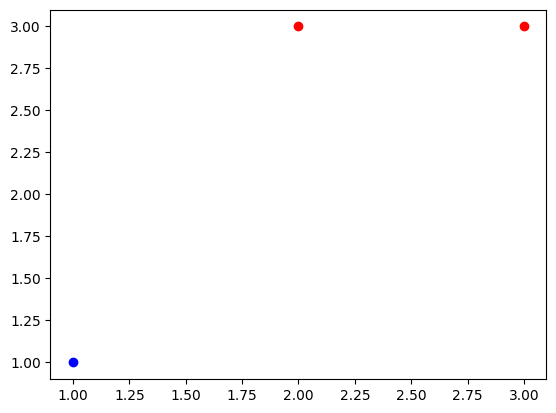

<Figure size 640x480 with 0 Axes>

In [12]:
plt.scatter(X[0, 0], X[0, 1], color='blue')
plt.scatter(X[1:3,0], X[1:3,1], color='red')
plt.show()
plt.clf()

In [13]:
model = LinearModel([2, 1], learning_rate=0.1, max_ep=1000, classification_algo="rosenblatt")
print("rosenblatt")

loss = model.train(X, Y)
print(f"Loss finale : {loss:.6f}")

rosenblatt
Loss finale : 0.146667


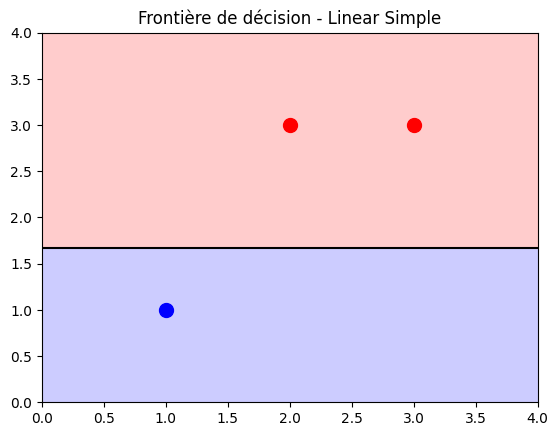

In [14]:
xx, yy = np.meshgrid(np.linspace(0, 4, 300), np.linspace(0, 4, 300))
grid = np.c_[xx.ravel(), yy.ravel()]

scores = np.array([model.forward(pt)[0] for pt in grid]).reshape(xx.shape)

plt.contourf(xx, yy, scores, levels=[-np.inf, 0, np.inf], colors=['#ffaaaa', '#aaaaff'], alpha=0.6)
plt.contour(xx, yy, scores, levels=[0], colors='black', linewidths=1.5)
plt.scatter(X[0, 0], X[0, 1], color='blue', s=100, zorder=5)
plt.scatter(X[1:3, 0], X[1:3, 1], color='red', s=100, zorder=5)
plt.title("Frontière de décision - Linear Simple")
plt.show()

In [15]:
print("Point     | Sortie | Attendu")
print("-" * 35)
for x, exp in zip(X, [1, -1, -1]):
    
    out = model.forward(x)[0]
    print(f"  {x}  →  {out:+.4f}  (attendu {exp:+d})")


Point     | Sortie | Attendu
-----------------------------------
  [1 1]  →  +0.4000  (attendu +1)
  [2 3]  →  -0.8000  (attendu -1)
  [3 3]  →  -0.8000  (attendu -1)


### Linear Multiple

In [9]:
X = np.concatenate([np.random.random((50,2)) * 0.9 + np.array([1, 1]), np.random.random((50,2)) * 0.9 + np.array([2, 2])])
Y = np.concatenate([np.ones((50, 1)), np.ones((50, 1)) * -1.0])

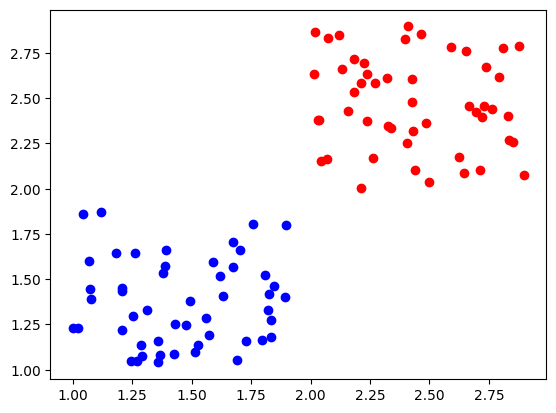

<Figure size 640x480 with 0 Axes>

In [ ]:
plt.scatter(X[0:50, 0], X[0:50, 1], color='blue')
plt.scatter(X[50:100,0], X[50:100,1], color='red')
plt.show()
plt.clf()

In [10]:
model = LinearModel([2, 1], learning_rate=0.1, max_ep=1000, classification_algo="rosenblatt")
print("Algo utilisé : rosenblatt")

loss = model.train(X, Y)
print(f"Loss finale : {loss:.6f}")

Algo utilisé : rosenblatt
Loss finale : 0.593551


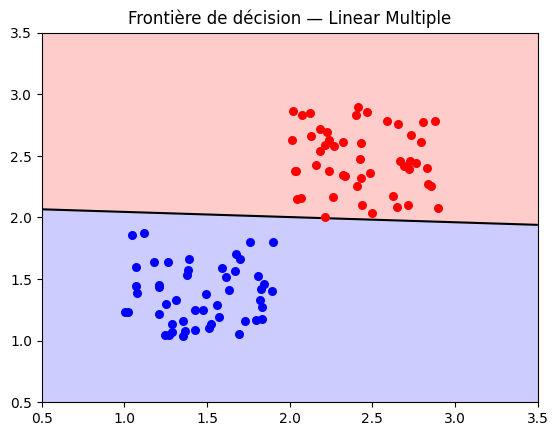

In [ ]:
xx, yy = np.meshgrid(np.linspace(0.5, 3.5, 300), np.linspace(0.5, 3.5, 300))
grid = np.c_[xx.ravel(), yy.ravel()]

scores = np.array([model.forward(pt)[0] for pt in grid]).reshape(xx.shape)

plt.contourf(xx, yy, scores, levels=[-np.inf, 0, np.inf], colors=['#ffaaaa', '#aaaaff'], alpha=0.6)
plt.contour(xx, yy, scores, levels=[0], colors='black', linewidths=1.5)
plt.scatter(X[0:50, 0],   X[0:50, 1],   color='blue', s=30, zorder=5)
plt.scatter(X[50:100, 0], X[50:100, 1], color='red',  s=30, zorder=5)
plt.title("Frontière de décision — Linear Multiple")
plt.show()

In [ ]:
labels = np.concatenate([np.zeros(50), np.ones(50)]) 
acc = model.accuracy(X, labels)
print(f"Accuracy : {acc * 100:.1f}%")

cm = model.confusion_matrix(X, labels)
print("Matrice de confusion :")
print(cm)

Accuracy : 0.0%
Matrice de confusion :
[[ 0 50]
 [50  0]]


### XOR

In [ ]:
X = np.array([[1, 0], [0, 1], [0, 0], [1, 1]])
Y = np.array([1, 1, -1, -1])

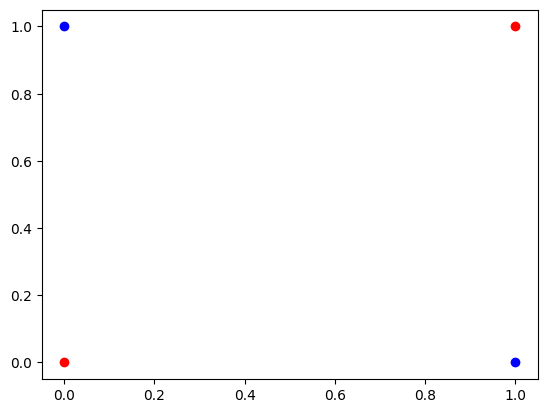

<Figure size 640x480 with 0 Axes>

In [ ]:
plt.scatter(X[0:2, 0], X[0:2, 1], color='blue')
plt.scatter(X[2:4,0], X[2:4,1], color='red')
plt.show()
plt.clf()

Loss finale : 1.100000


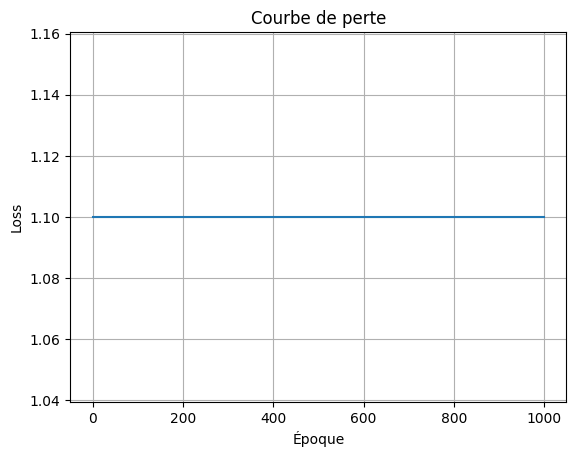

In [ ]:
model = LinearModel([2, 2, 1], learning_rate=0.1, max_ep=1000)

loss = model.train(X, Y)
print(f"Loss finale : {loss:.6f}")

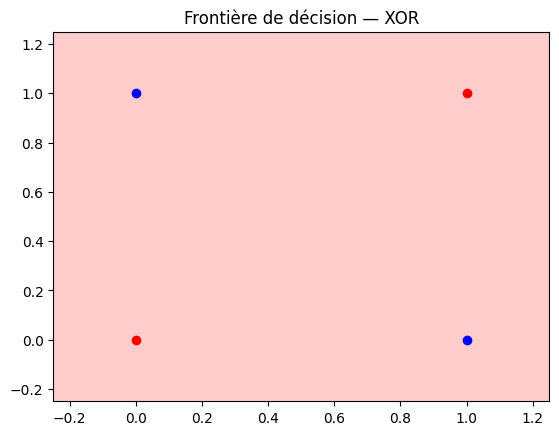

In [ ]:
xx, yy = np.meshgrid(np.linspace(-0.25, 1.25, 300), np.linspace(-0.25, 1.25, 300))
grid = np.c_[xx.ravel(), yy.ravel()]

scores = np.array([model.forward(pt)[0] for pt in grid]).reshape(xx.shape)

plt.contourf(xx, yy, scores, levels=[-np.inf, 0, np.inf], colors=['#ffaaaa', '#aaaaff'], alpha=0.6)
plt.contour(xx, yy, scores, levels=[0], colors='black', linewidths=1.5)
plt.scatter(X[0:2, 0], X[0:2, 1], color='blue')
plt.scatter(X[2:4,0], X[2:4,1], color='red')
plt.title("Frontière de décision — XOR")
plt.show()


### Cross

In [ ]:
X = np.random.random((500, 2)) * 2.0 - 1.0
Y = np.array([1 if abs(p[0]) <= 0.3 or abs(p[1]) <= 0.3 else -1 for p in X])

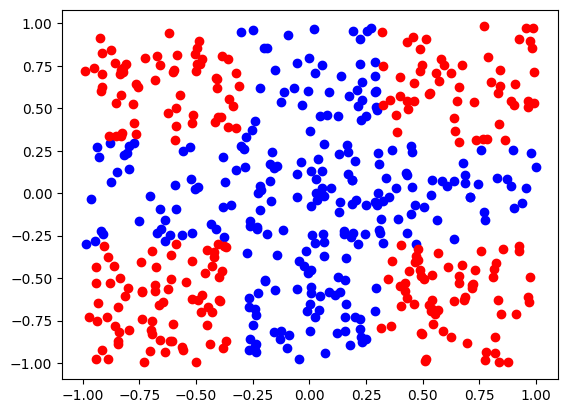

<Figure size 640x480 with 0 Axes>

In [ ]:
plt.scatter(np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]] == 1, enumerate(X)))))[:,0], np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]] == 1, enumerate(X)))))[:,1], color='blue')
plt.scatter(np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]] == -1, enumerate(X)))))[:,0], np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]] == -1, enumerate(X)))))[:,1], color='red')
plt.show()
plt.clf()

Loss finale : 2.114107


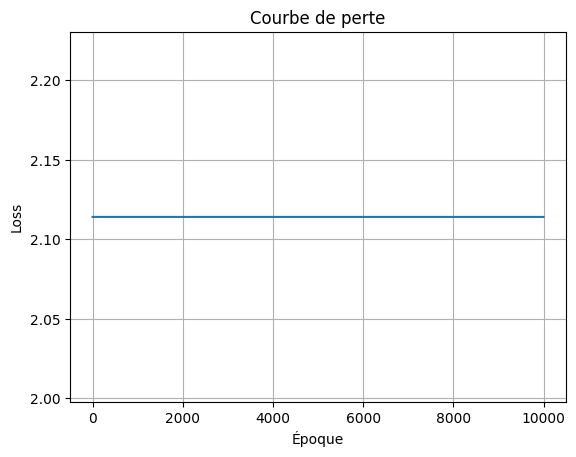

In [ ]:
model = LinearModel([2, 4, 1], learning_rate=0.5, max_ep=10000)

loss = model.train(X, Y)
print(f"Loss finale : {loss:.6f}")

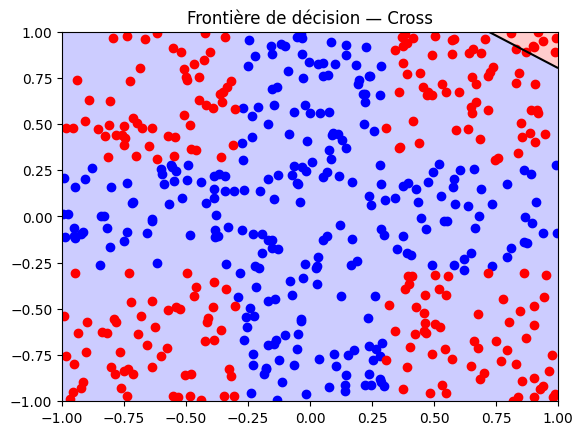

In [ ]:
xx, yy = np.meshgrid(np.linspace(-1, 1, 300), np.linspace(-1, 1, 300))
grid = np.c_[xx.ravel(), yy.ravel()]

scores = np.array([model.forward(pt)[0] for pt in grid]).reshape(xx.shape)

plt.contourf(xx, yy, scores, levels=[-np.inf, 0, np.inf], colors=['#ffaaaa', '#aaaaff'], alpha=0.6)
plt.contour(xx, yy, scores, levels=[0], colors='black', linewidths=1.5)
plt.scatter(np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]] == 1, enumerate(X)))))[:,0], np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]] == 1, enumerate(X)))))[:,1], color='blue')
plt.scatter(np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]] == -1, enumerate(X)))))[:,0], np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]] == -1, enumerate(X)))))[:,1], color='red')
plt.title("Frontière de décision — Cross")
plt.show()


### Multi Linear 3 classes

In [ ]:
X = np.random.random((500, 2)) * 2.0 - 1.0
Y = np.array([[1, -1, -1] if -p[0] - p[1] - 0.5 > 0 and p[1] < 0 and p[0] - p[1] - 0.5 < 0 else
              [-1, 1, -1] if -p[0] - p[1] - 0.5 < 0 and p[1] > 0 and p[0] - p[1] - 0.5 < 0 else
              [-1, -1, 1] if -p[0] - p[1] - 0.5 < 0 and p[1] < 0 and p[0] - p[1] - 0.5 > 0 else
              [-1, -1, -1]for p in X])

X = X[[not np.all(arr == [-1, -1, -1]) for arr in Y]]
Y = Y[[not np.all(arr == [-1, -1, -1]) for arr in Y]]

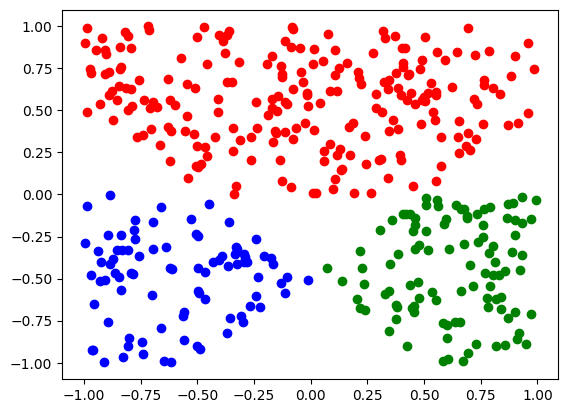

<Figure size 640x480 with 0 Axes>

In [ ]:
plt.scatter(np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][0] == 1, enumerate(X)))))[:,0], np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][0] == 1, enumerate(X)))))[:,1], color='blue')
plt.scatter(np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][1] == 1, enumerate(X)))))[:,0], np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][1] == 1, enumerate(X)))))[:,1], color='red')
plt.scatter(np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][2] == 1, enumerate(X)))))[:,0], np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][2] == 1, enumerate(X)))))[:,1], color='green')
plt.show()
plt.clf()

Loss finale : 6.118418


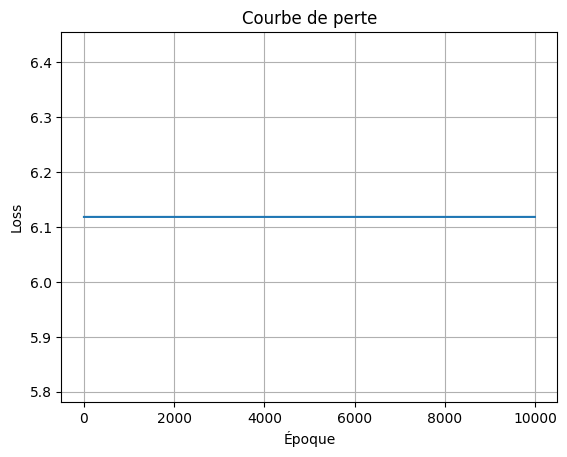

In [ ]:
model = LinearModel([2, 3], learning_rate=0.5, max_ep=10000, classification_algo="rosenblatt")
print("Algo utilisé : rosenblatt")

loss = model.train(X, Y)
print(f"Loss finale : {loss:.6f}")

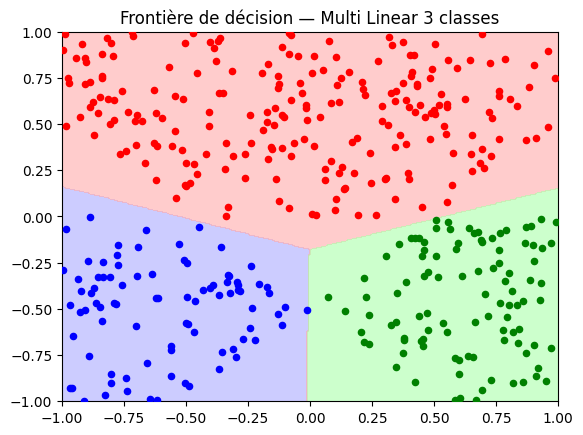

In [ ]:
xx, yy = np.meshgrid(np.linspace(-1, 1, 300), np.linspace(-1, 1, 300))
grid = np.c_[xx.ravel(), yy.ravel()]

preds = np.array([model.forward(pt) for pt in grid])
classes = np.argmax(preds, axis=1).reshape(xx.shape)

plt.contourf(xx, yy, classes, levels=[-0.5, 0.5, 1.5, 2.5],
             colors=['#aaaaff', '#ffaaaa', '#aaffaa'], alpha=0.6)

blue = X[Y[:, 0] == 1]
red = X[Y[:, 1] == 1]
green = X[Y[:, 2] == 1]

plt.scatter(blue[:,0], blue[:,1], color='blue', s=20, zorder=5)
plt.scatter(red[:,0], red[:,1], color='red', s=20, zorder=5)
plt.scatter(green[:,0], green[:,1], color='green', s=20, zorder=5)

plt.title("Frontière de décision — Multi Linear 3 classes")
plt.show()

### Multi Cross

In [ ]:
X = np.random.random((1000, 2)) * 2.0 - 1.0
Y = np.array([[1, -1, -1] if abs(p[0] % 0.5) <= 0.25 and abs(p[1] % 0.5) > 0.25 else [-1, 1, -1] if abs(p[0] % 0.5) > 0.25 and abs(p[1] % 0.5) <= 0.25 else [-1, -1, 1] for p in X])

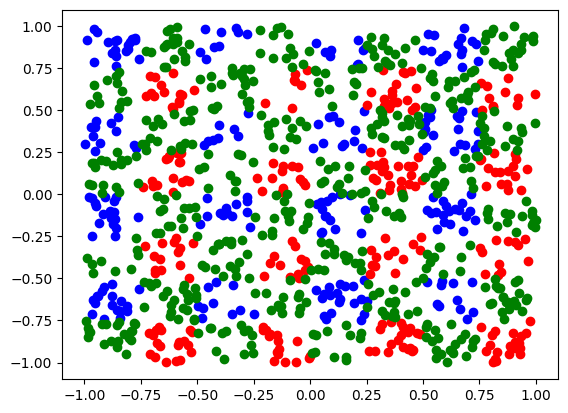

<Figure size 640x480 with 0 Axes>

In [ ]:
plt.scatter(np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][0] == 1, enumerate(X)))))[:,0], np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][0] == 1, enumerate(X)))))[:,1], color='blue')
plt.scatter(np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][1] == 1, enumerate(X)))))[:,0], np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][1] == 1, enumerate(X)))))[:,1], color='red')
plt.scatter(np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][2] == 1, enumerate(X)))))[:,0], np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][2] == 1, enumerate(X)))))[:,1], color='green')
plt.show()
plt.clf()

Loss finale : 0.324817


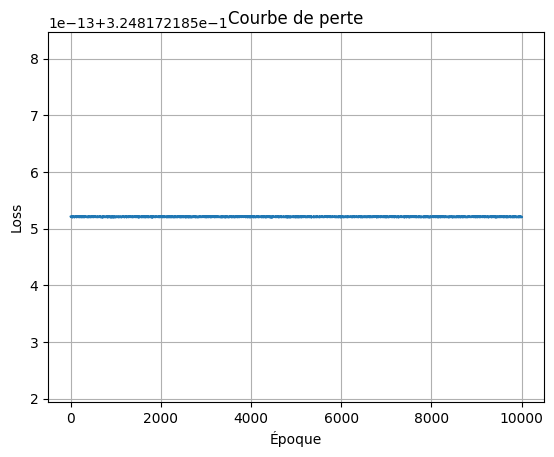

In [ ]:
model = LinearModel([2, 32, 32, 3], learning_rate=0.01, max_ep=10000)

loss = model.train(X, Y)
print(f"Loss finale : {loss:.6f}")

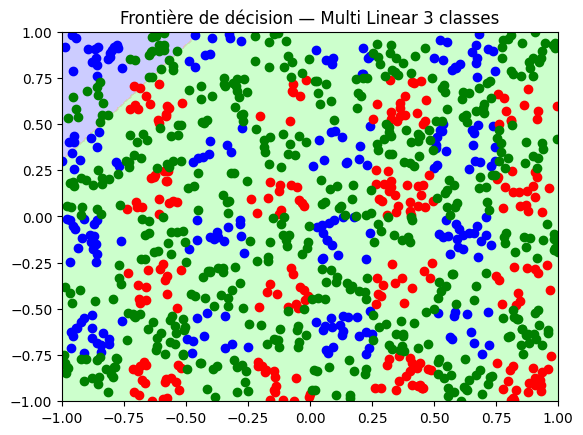

In [ ]:
xx, yy = np.meshgrid(np.linspace(-1, 1, 300), np.linspace(-1, 1, 300))
grid = np.c_[xx.ravel(), yy.ravel()]

preds = np.array([model.forward(pt) for pt in grid])
classes = np.argmax(preds, axis=1).reshape(xx.shape)

plt.contourf(xx, yy, classes, levels=[-0.5, 0.5, 1.5, 2.5],
             colors=['#aaaaff', '#ffaaaa', '#aaffaa'], alpha=0.6)

blue = X[Y[:, 0] == 1]
red = X[Y[:, 1] == 1]
green = X[Y[:, 2] == 1]

plt.scatter(blue[:,0], blue[:,1], color='blue')
plt.scatter(red[:,0], red[:,1], color='red')
plt.scatter(green[:,0], green[:,1], color='green')

plt.title("Frontière de décision — Multi Cross")
plt.show()

## Régression

### Linear Simple 2D

In [ ]:
X = np.array([
      [1],
      [2]
])
Y = np.array([
      2,
      3
])

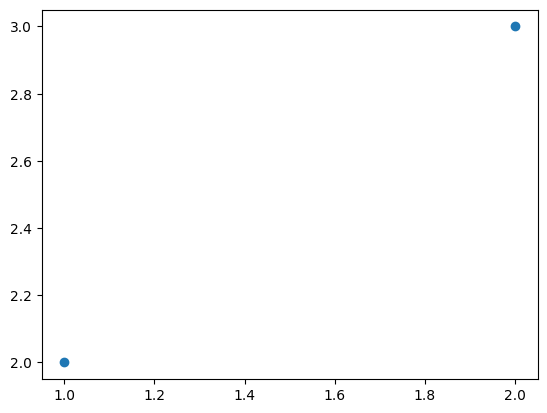

<Figure size 640x480 with 0 Axes>

In [ ]:
plt.scatter(X,Y)
plt.show()
plt.clf()

Loss finale : 0.000000


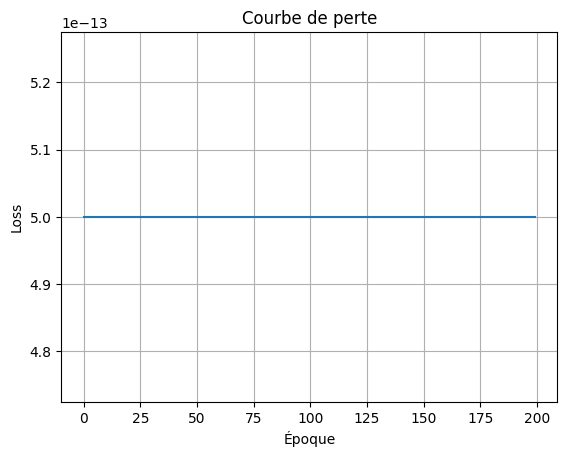

In [ ]:
model = LinearModel([1, 1], learning_rate=0.1, is_regression=True)

loss = model.train(X, Y)
print(f"Loss finale : {loss:.6f}")

/var/folders/8f/bzlpbhb14kb7tsd0cxv549480000gn/T/ipykernel_78571/2296348798.py:147: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return np.array([float(xb @ self.w_reg)], dtype=np.float64)


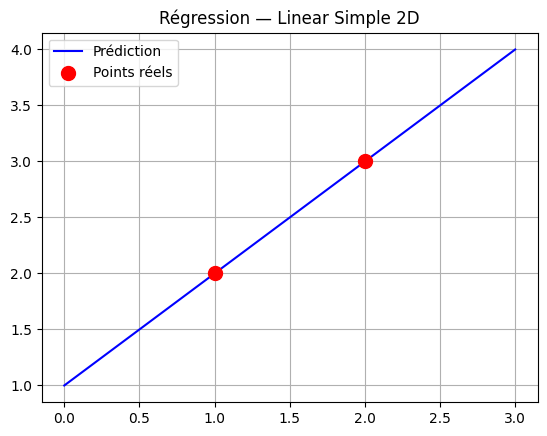

In [ ]:
x_range = np.linspace(0, 3, 300).reshape(-1, 1)
y_pred = np.array([model.forward(pt)[0] for pt in x_range])

plt.plot(x_range, y_pred, color='blue', label='Prédiction')
plt.scatter(X, Y, color='red', s=100, zorder=5, label='Points réels')
plt.title("Régression — Linear Simple 2D")
plt.legend(); 
plt.grid(True)
plt.show()

### Non Linear Simple 2D

In [ ]:
X = np.array([
      [1],
      [2],
      [3]
])
Y = np.array([
      2,
      3,
      2.5
])

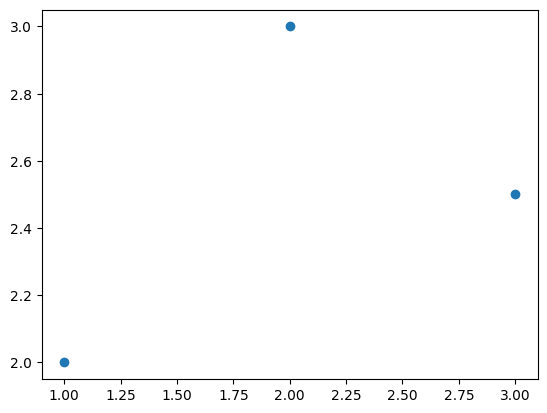

<Figure size 640x480 with 0 Axes>

In [ ]:
plt.scatter(X,Y)
plt.show()
plt.clf()

Loss finale : 0.125000


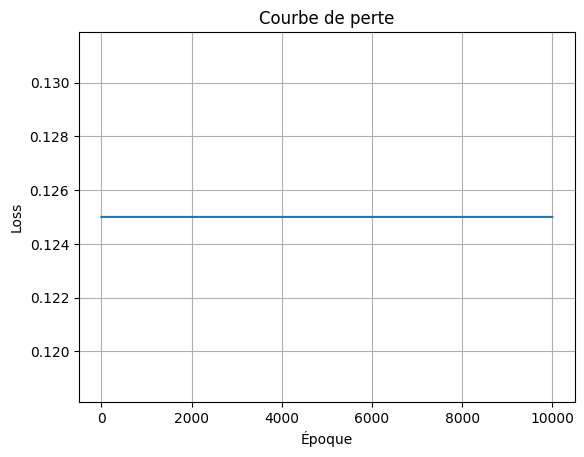

In [ ]:
model = LinearModel([1, 4, 1], learning_rate=0.1, is_regression=True)

loss = model.train(X, Y)
print(f"Loss finale : {loss:.6f}")

/var/folders/8f/bzlpbhb14kb7tsd0cxv549480000gn/T/ipykernel_78571/2296348798.py:147: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return np.array([float(xb @ self.w_reg)], dtype=np.float64)


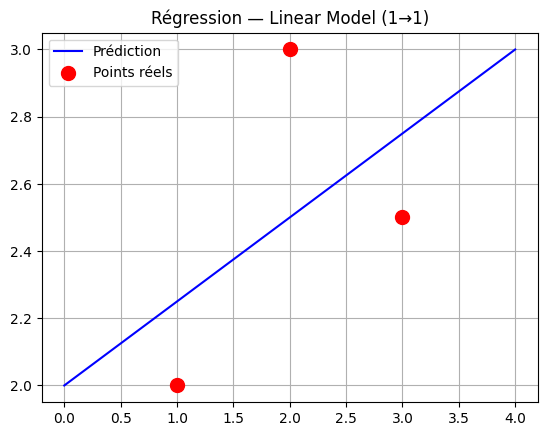

In [ ]:
x_range = np.linspace(0, 4, 300).reshape(-1, 1)
y_pred = np.array([model.forward(pt)[0] for pt in x_range])

plt.plot(x_range, y_pred, color='blue', label='Prédiction')
plt.scatter(X, Y, color='red', s=100, zorder=5, label='Points réels')
plt.title("Régression — Linear Model (1→1)")
plt.legend();
plt.grid(True)
plt.show()

### Linear Simple 3D

In [ ]:
X = np.array([
      [1, 1],
      [2, 2],
      [3, 1]
])
Y = np.array([
      2,
      3,
      2.5
])

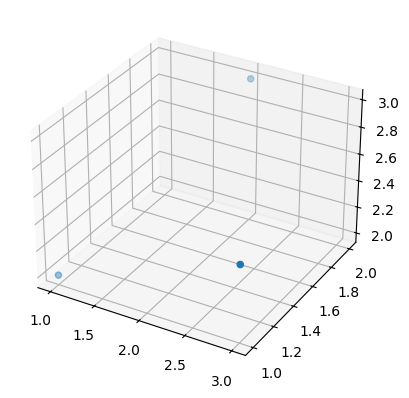

<Figure size 640x480 with 0 Axes>

In [ ]:
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X[:,0], X[:,1], Y)
plt.show()
plt.clf()

Loss finale : 0.000000


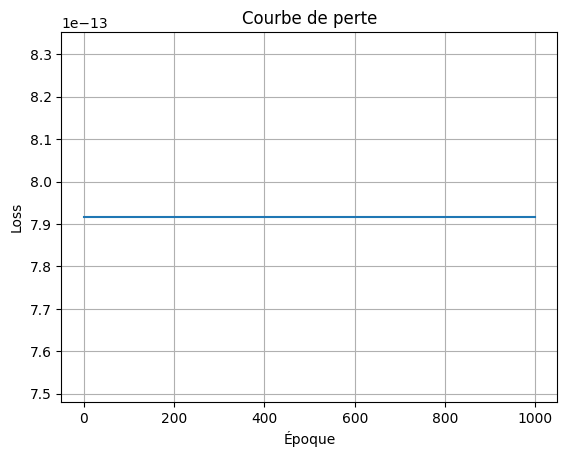

In [ ]:
model = LinearModel([2, 1], learning_rate=0.01, is_regression=True)

loss = model.train(X, Y)
print(f"Loss finale : {loss:.6f}")

/var/folders/8f/bzlpbhb14kb7tsd0cxv549480000gn/T/ipykernel_78571/2296348798.py:147: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return np.array([float(xb @ self.w_reg)], dtype=np.float64)


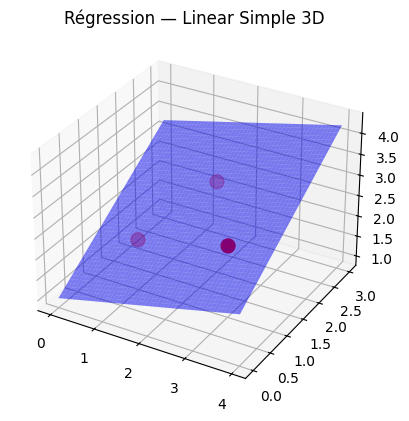

In [ ]:
x1_range = np.linspace(0, 4, 50)
x2_range = np.linspace(0, 3, 50)
xx1, xx2 = np.meshgrid(x1_range, x2_range)
grid = np.c_[xx1.ravel(), xx2.ravel()]

y_pred = np.array([model.forward(pt)[0] for pt in grid]).reshape(xx1.shape)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(xx1, xx2, y_pred, alpha=0.5, color='blue')
ax.scatter(X[:,0], X[:,1], Y, color='red', s=100, zorder=5, label='Points réels')
ax.set_title("Régression — Linear Simple 3D")
plt.show()

### Linear Tricky 3D

In [ ]:
X = np.array([
      [1, 1],
      [2, 2],
      [3, 3]
])
Y = np.array([
      1,
      2,
      3
])

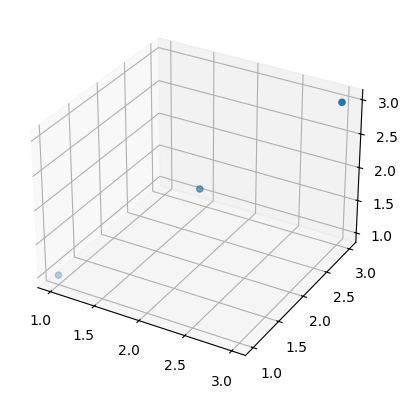

<Figure size 640x480 with 0 Axes>

In [ ]:
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X[:,0], X[:,1], Y)
plt.show()
plt.clf()

Loss finale : 0.000000


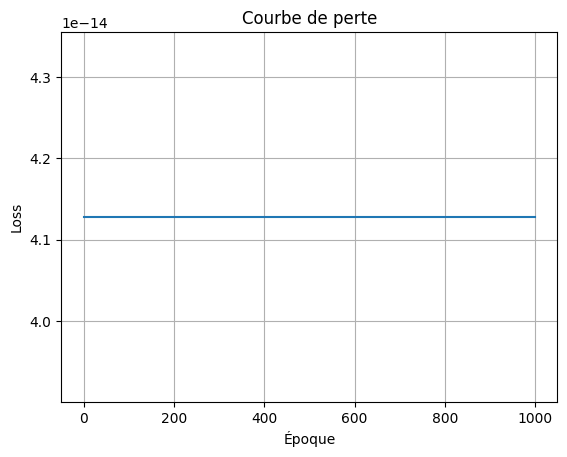

In [ ]:
model = LinearModel([2, 1], learning_rate=0.01, is_regression=True)

loss = model.train(X, Y)
print(f"Loss finale : {loss:.6f}")

/var/folders/8f/bzlpbhb14kb7tsd0cxv549480000gn/T/ipykernel_78571/2296348798.py:147: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return np.array([float(xb @ self.w_reg)], dtype=np.float64)


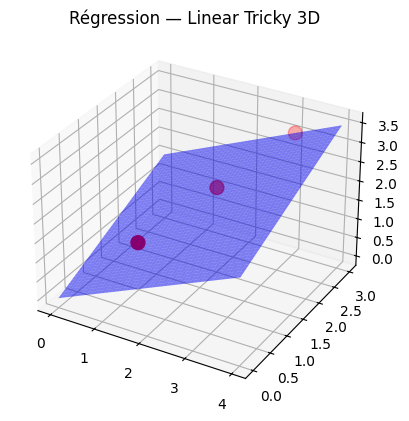

In [ ]:
x1_range = np.linspace(0, 4, 50)
x2_range = np.linspace(0, 3, 50)
xx1, xx2 = np.meshgrid(x1_range, x2_range)
grid = np.c_[xx1.ravel(), xx2.ravel()]

y_pred = np.array([model.forward(pt)[0] for pt in grid]).reshape(xx1.shape)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(xx1, xx2, y_pred, alpha=0.5, color='blue')
ax.scatter(X[:,0], X[:,1], Y, color='red', s=100, zorder=5, label='Points réels')
ax.set_title("Régression — Linear Tricky 3D")
plt.show()

### Non Linear Simple 3D

In [ ]:
X = np.array([
      [1, 0],
      [0, 1],
      [1, 1],
      [0, 0],
])
Y = np.array([
      2,
      1,
      -2,
      -1
])

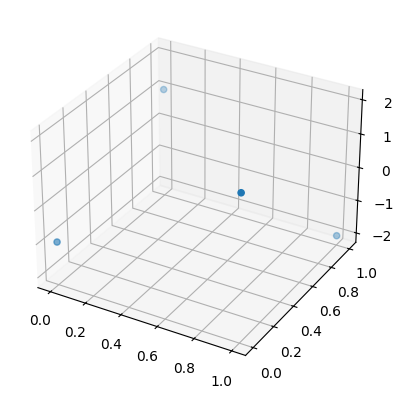

<Figure size 640x480 with 0 Axes>

In [ ]:
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X[:,0],X[:,1],Y)
plt.show()
plt.clf()

Loss finale : 0.000000


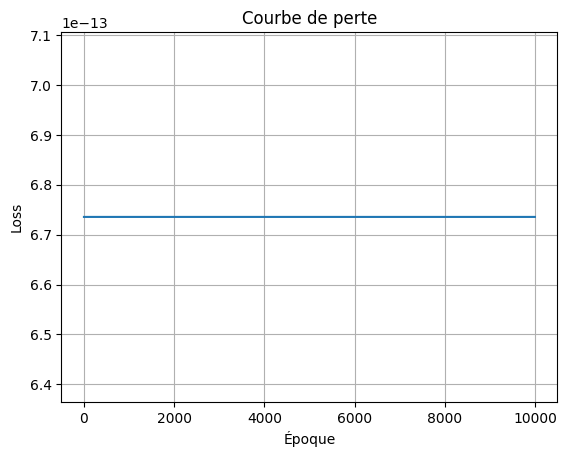

In [ ]:
model = LinearModel([2, 2, 1], learning_rate=0.001, is_regression=True)

loss = model.train(X, Y)
print(f"Loss finale : {loss:.6f}")

/var/folders/8f/bzlpbhb14kb7tsd0cxv549480000gn/T/ipykernel_78571/2296348798.py:147: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return np.array([float(xb @ self.w_reg)], dtype=np.float64)


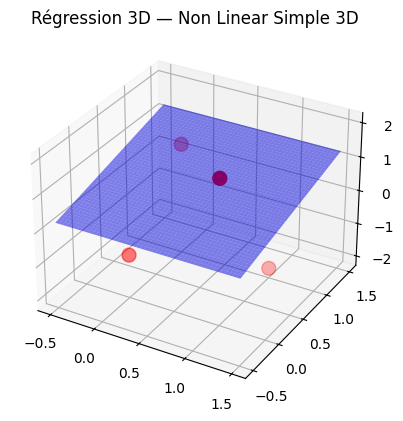

In [ ]:
x1_range = np.linspace(-0.5, 1.5, 50)
x2_range = np.linspace(-0.5, 1.5, 50)
xx1, xx2 = np.meshgrid(x1_range, x2_range)
grid = np.c_[xx1.ravel(), xx2.ravel()]

y_pred = np.array([model.forward(pt)[0] for pt in grid]).reshape(xx1.shape)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(xx1, xx2, y_pred, alpha=0.5, color='blue')
ax.scatter(X[:,0], X[:,1], Y, color='red', s=100, zorder=5, label='Points réels')
ax.set_title("Régression 3D — Non Linear Simple 3D")
plt.show()